<a href="https://colab.research.google.com/github/Nasuz092/Google-Colab-Sentimen-Analisis-/blob/main/Sentimen_Analisis_2_0_(Youtube_Comment)_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Instalasi yang diperlukan**

In [36]:
!pip install langdetect

In [37]:
!pip install plotly

#**Instalasi yang gk perlu di RUN, kecuali ada saat tertentu**
Note: digunakan hanya saat nge RUN "Import Torch" kemudian muncul Error

In [34]:
!pip uninstall torch torchvision torchaudio -y
!pip cache purge

Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0
Found existing installation: torchvision 0.21.0
Uninstalling torchvision-0.21.0:
  Successfully uninstalled torchvision-0.21.0
Found existing installation: torchaudio 2.6.0
Uninstalling torchaudio-2.6.0:
  Successfully uninstalled torchaudio-2.6.0
Files removed: 0


In [35]:
!pip install torch torchvision torchaudio --no-cache-dir

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

#**Tahap Import Library**

In [38]:
#Library buat Pre Processing / Cleansing Data
import pandas as pd
import numpy as np
import requests
from io import StringIO
from langdetect import detect
import re
import regex as re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
import unicodedata

#Library buat Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Library buat Proses Labeling
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline
import torch

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#**Proses *Pre Proccessing* Data**

In [39]:
# URL raw dataset CSV dari GitHub
df=pd.read_csv("https://raw.githubusercontent.com/Nasuz092/Dataset-Twitter/refs/heads/main/yt-comments-lol2025%20(4).csv", sep= ',')
df.head(3)

def load_sentiment_dict_hybrid(file_path):
    sentiment_dict = {}
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if ':' in line:
                key, value = line.strip().split(':', 1)
                try:
                    score = float(value.strip())

                    # Jika negatif (-5 sampai -1)
                    if -5 <= score <= -1:
                        final_score = abs(score)  # Konversi simple
                    # Jika positif (1 sampai 5)
                    elif 1 <= score <= 5:
                        final_score = score
                    # Jika di luar range
                    else:
                        print(f"Nilai diabaikan (harus -5 sampai -1 atau 1 sampai 5): {key}:{score}")
                        continue

                    sentiment_dict[key.strip()] = final_score
                except ValueError:
                    print(f"Nilai tidak valid diabaikan: {key}:{value}")
    return sentiment_dict


sentiment_dict_path = '/content/0-Combined-Multilingual.txt'
sentiment_dict = load_sentiment_dict_hybrid(sentiment_dict_path)

In [40]:
# Menghapus Kolom yang tidak digunakan
df = df.drop(columns=['publishedAt',	'authorDisplayName'], axis=1)

# Menghapus data yang memiliki nilai NaN dalam kolom tertentu
df = df.dropna(subset=['textDisplay',	'likeCount'])

# Menghapus nilai yang Duplikat atau sama persis
df = df.drop_duplicates(subset=['textDisplay'])
df.head(5)

,textDisplay,likeCount
0,Darius its a till lindemann ?,0.0
1,sortez nous des épisodes tellement c’est incro...,0.0
2,I wanna see more the Katarina riot games pleas...,0.0
3,mordekaiser por favor,1.0
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0


In [41]:
def remove_pattern(Text, pattern):
    r = re.findall(pattern, str(Text))
    for i in r:
        Text = re.sub(i, '', str(Text))
    return Text
df['remove_user'] = np.vectorize(remove_pattern)(df['textDisplay'], "@[\w]*")

In [42]:
def cleaning(Text):
    Text = re.sub(r"<a\s+href='https:\/\/www\.youtube\.com\/watch\?v=[^']+(&t=[0-9ms]+)?'>[^<]+<\/a>", "", Text)
    Text = re.sub(r"<a\s+href='(?:https?:\/\/)?(?:www\.)?youtube\.com[^']*(&t=[0-9ms]+)?'>[^<]+<\/a>", "", Text)
    Text = re.sub(r"<br\s*\/?>", "", Text)
    Text = Text.replace("&#39;", "")
    Text = re.sub(r"&lrm;", "", Text)
    Text = re.sub(r"&zwnj;", "", Text)
    Text = re.sub(r'\s&amp\s', ' ', Text)
    Text = re.sub(r'$\w*', '', Text)
    Text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', ' ', Text)
    Text = re.sub(r"\d+", " ", str(Text))
    Text = re.sub(r"\s+", " ", str(Text))
    Text = re.sub(r'#', '', Text)
    Text = re.sub(r'\s\s+', ' ', Text)
    Text = re.sub(r'^b[\s]+', '', Text)
    Text = re.sub(r'^link[\s]+', '', Text)
    Text = re.sub(r"<\/?[a-z]+>", "", Text)
    Text = re.sub(r"<a\s+[^>]*>", "", Text)
    return Text

def remove_emoji(Text):
    emoji = re.compile("["
                        u"\U0001F600-\U0001F64F"  # emoticons
                        u"\U0001F300-\U0001F5FF"  # simbol & piktogram
                        u"\U0001F680-\U0001F6FF"  # transportasi & simbol peralatan
                        u"\U0001F1E0-\U0001F1FF"  # bendera negara
                        u"\U00002702-\U000027B0"  # simbol
                        u"\U000024C2-\U0001F251"  # emoji lainnya
                        "]+", flags=re.UNICODE)
    return emoji.sub(r'', Text)

df['cleaning'] = df['remove_user'].apply(cleaning)

In [43]:
def tokenize_with_quotes(text):
    tokens = word_tokenize(text)
    tokens_with_quotes = ['"' + token + '"' for token in tokens]
    return tokens_with_quotes

df['tokenized_Content'] = df['textDisplay'].apply(lambda x: tokenize_with_quotes(x))
df.head(6)

,textDisplay,likeCount,remove_user,cleaning,tokenized_Content
0,Darius its a till lindemann ?,0.0,Darius its a till lindemann ?,Darius its a till lindemann ?,"[""Darius"", ""its"", ""a"", ""till"", ""lindemann"", ""?""]"
1,sortez nous des épisodes tellement c’est incro...,0.0,sortez nous des épisodes tellement c’est incro...,sortez nous des épisodes tellement c’est incro...,"[""sortez"", ""nous"", ""des"", ""épisodes"", ""telleme..."
2,I wanna see more the Katarina riot games pleas...,0.0,I wanna see more the Katarina riot games pleas...,I wanna see more the Katarina riot games pleas...,"[""I"", ""wan"", ""na"", ""see"", ""more"", ""the"", ""Kata..."
3,mordekaiser por favor,1.0,mordekaiser por favor,mordekaiser por favor,"[""mordekaiser"", ""por"", ""favor""]"
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0,"The symbol Vlad and Le Blanc are looking at, I...","The symbol Vlad and Le Blanc are looking at, I...","[""The"", ""symbol"", ""Vlad"", ""and"", ""Le"", ""Blanc""..."
5,i dont understand how can some people say that...,0.0,i dont understand how can some people say that...,i dont understand how can some people say that...,"[""i"", ""dont"", ""understand"", ""how"", ""can"", ""som..."


In [44]:
def clean_text(text):
    # Bersihkan teks dari karakter khusus
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.lower().strip()
    return text

def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unknown'

# Tambahkan kolom bahasa dan teks bersih
df['cleaned_text'] = df['cleaning'].apply(clean_text)
df['language'] = df['cleaned_text'].apply(detect_language)

# Tampilkan distribusi bahasa
print(df['language'].value_counts())

language
en         14167
pt           740
es           713
af           578
so           515
it           408
et           368
ca           303
fr           300
cy           293
ru           281
ko           266
tl           261
tr           250
nl           199
id           199
no           186
sw           183
da           181
pl           172
unknown      160
lt           148
fi           136
ro           126
sv           109
sl           109
hr            59
sk            58
vi            54
hu            47
de            46
sq            40
cs            26
th            24
lv            19
ar            19
mk            19
uk            17
bg            10
ja             9
fa             7
zh-cn          7
zh-tw          5
el             4
ur             2
Name: count, dtype: int64


#**Proses Labeling**
Note: proses ini makan waktu lebih lama, jd di pantau terus jangan sampai *connection runtime out*

In [45]:
# Load model BERT multibahasa yang sudah fine-tuned untuk analisis sentimen
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Buat pipeline untuk analisis sentimen
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

def bert_sentiment(text):
    try:
        result = sentiment_analyzer(text[:1024])  # Batasi panjang teks untuk BERT
        label = result[0]['label']
        score = result[0]['score']

        # Konversi label ke skor numerik (1-5)
        rating = int(label.split()[0])
        # Normalisasi ke skala -1 (negatif) hingga 1 (positif)
        normalized_score = (rating - 3) / 2
        return normalized_score * score  # Gabungkan rating dengan confidence score
    except:
        return 0  # Netral jika error

Device set to use cpu


In [46]:
def dictionary_based_sentiment(text, language):
    words = text.split()
    total_score = 0
    matched_words = 0

    for word in words:
        if word in sentiment_dict:
            total_score += sentiment_dict[word]
            matched_words += 1

    if matched_words > 0:
        return total_score / matched_words
    return 0  # Netral jika tidak ada kata yang cocok

def hybrid_sentiment_analysis(row):
    # Daftar bahasa yang didukung baik oleh BERT dan kamus
    supported_by_bert = ['en', 'fr', 'de', 'es', 'it', 'pt', 'nl', 'ru', 'zh', 'ja']

    if row['language'] in supported_by_bert:
        return bert_sentiment(row['cleaned_text'])
    else:
        return dictionary_based_sentiment(row['cleaned_text'], row['language'])

# Terapkan analisis sentimen hybrid
df['sentiment_score'] = df.apply(hybrid_sentiment_analysis, axis=1)

# Kategorikan sentimen
def categorize_sentiment(score):
    if score > 0.2:
        return 'positive'
    elif score < -0.2:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['sentiment_score'].apply(categorize_sentiment)

#**Prosess Visualisasi**

In [47]:
# Cek style yang tersedia
print("Available styles:", plt.style.available)

# Ganti 'seaborn' dengan style yang tersedia, misalnya:
plt.style.use('seaborn-v0_8')  # Untuk versi Matplotlib >= 3.6
# atau
plt.style.use('ggplot')  # Alternatif populer

Available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


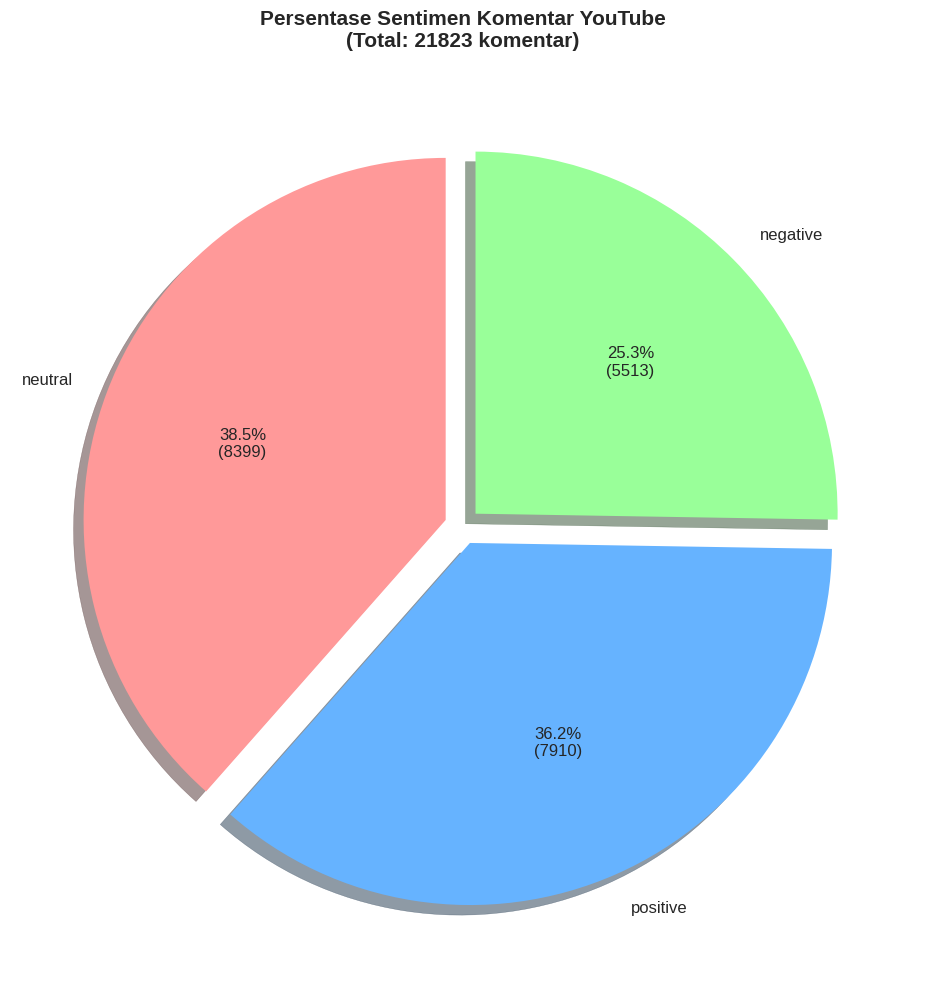

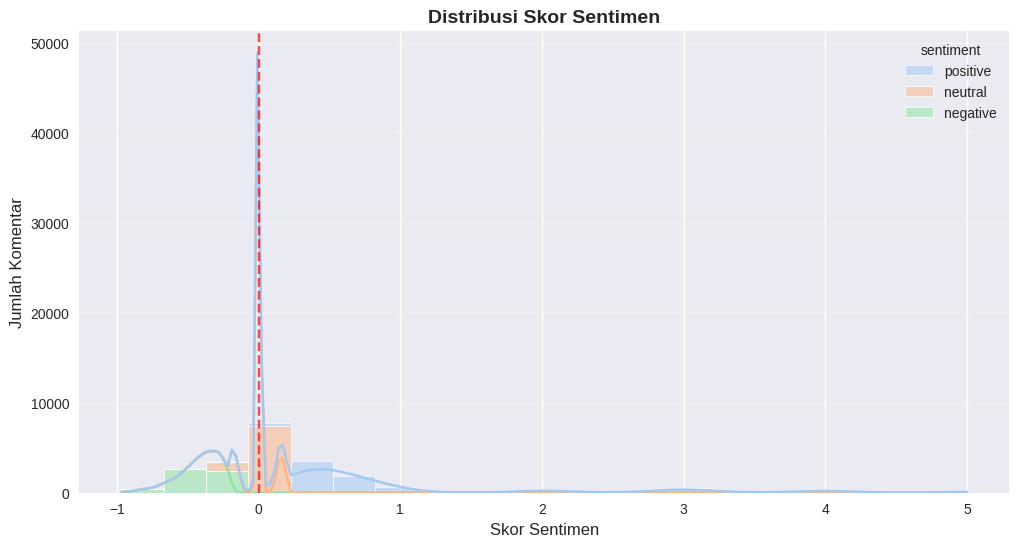

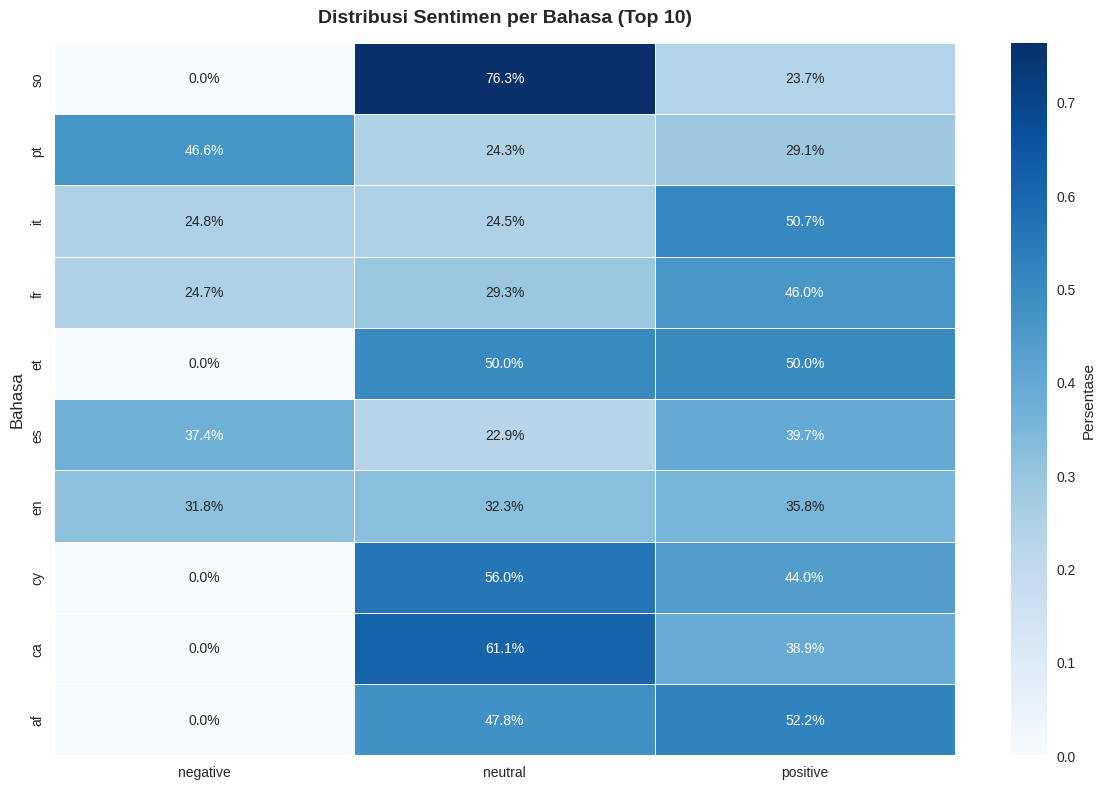

In [48]:
# 1. Set style yang valid
plt.style.use('seaborn-v0_8')  # atau 'ggplot', 'bmh', 'dark_background', dll
sns.set_palette("pastel")

# 2. PIE CHART - Distribusi Sentimen
plt.figure(figsize=(10, 10))
sentiment_counts = df['sentiment'].value_counts()
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p/100*sentiment_counts.sum())})',
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    shadow=True,
    colors=['#ff9999','#66b3ff','#99ff99'],
    textprops={'fontsize': 12}
)
plt.title('Persentase Sentimen Komentar YouTube\n(Total: {} komentar)'.format(len(df)),
          pad=20, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Histogram dengan Density Plot
plt.figure(figsize=(12, 6))
ax = sns.histplot(
    data=df,
    x='sentiment_score',
    bins=20,
    kde=True,
    hue='sentiment',
    multiple='stack',
    edgecolor='white',
    linewidth=0.5
)
plt.title('Distribusi Skor Sentimen', fontsize=14, fontweight='bold')
plt.xlabel('Skor Sentimen', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.grid(axis='y', alpha=0.3)
sns.despine()
plt.show()

# 4. Heatmap Sentimen per Bahasa (Top 10)
top_langs = df['language'].value_counts().nlargest(10).index
df_top = df[df['language'].isin(top_langs)]

plt.figure(figsize=(12, 8))
heatmap_data = pd.crosstab(
    df_top['language'],
    df_top['sentiment'],
    normalize='index'
).sort_index(ascending=False)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Persentase'}
)
plt.title('Distribusi Sentimen per Bahasa (Top 10)',
          pad=15, fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Bahasa', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

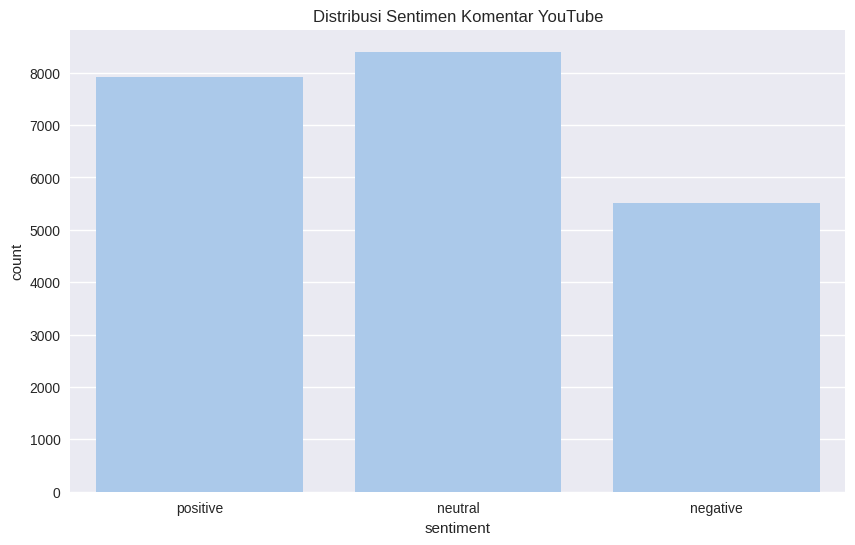

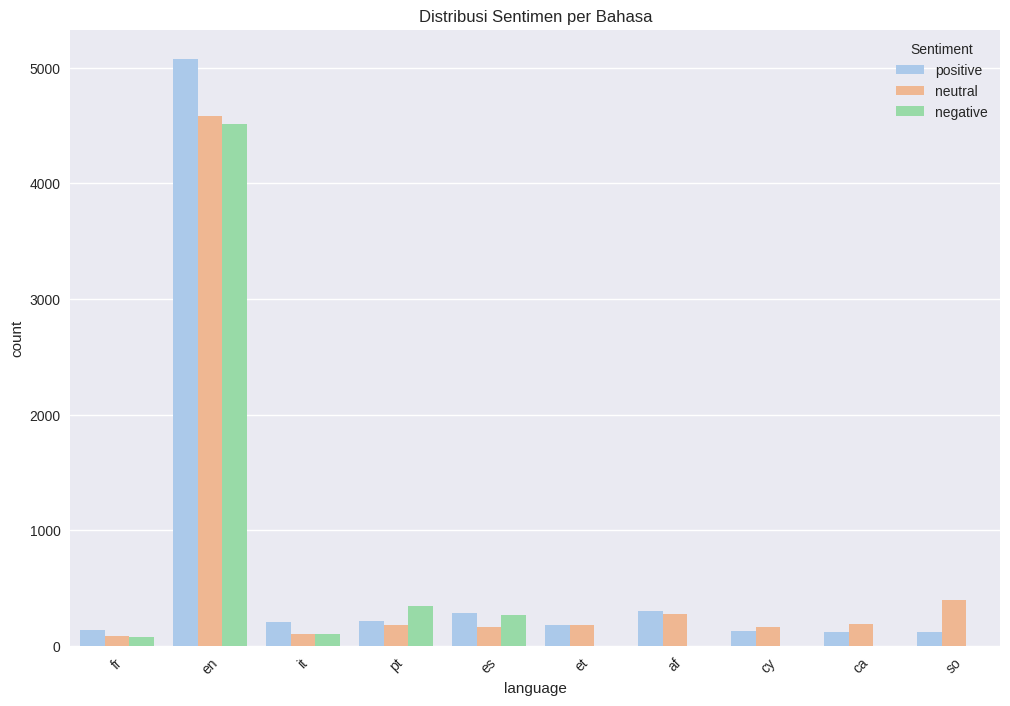

<ipython-input-49-4015f551f650>:20: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




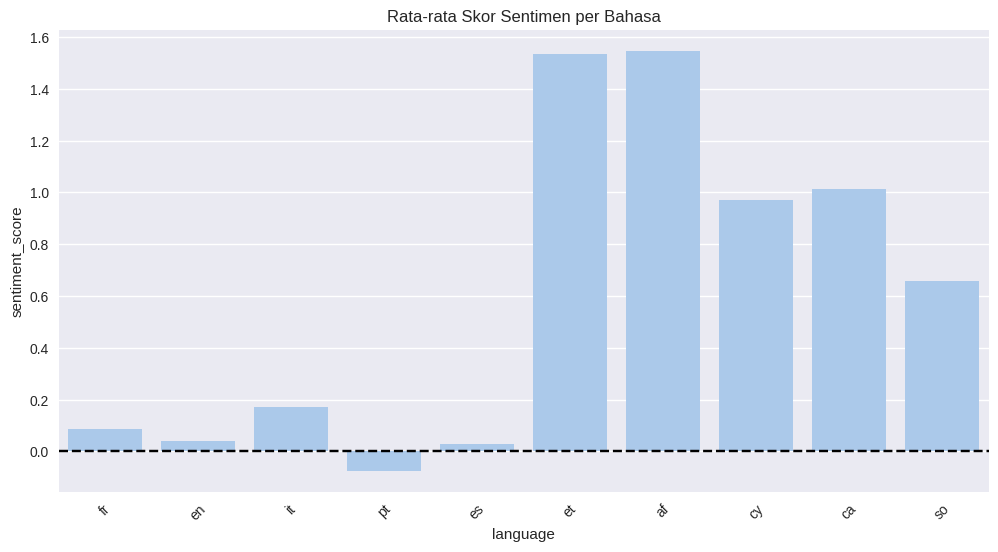

In [49]:
# Distribusi sentimen keseluruhan
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=df)
plt.title('Distribusi Sentimen Komentar YouTube')
plt.show()

# Distribusi sentimen per bahasa
top_languages = df['language'].value_counts().head(10).index.tolist()
df_top_langs = df[df['language'].isin(top_languages)]

plt.figure(figsize=(12, 8))
sns.countplot(x='language', hue='sentiment', data=df_top_langs)
plt.title('Distribusi Sentimen per Bahasa')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()

# Rata-rata skor sentimen per bahasa
plt.figure(figsize=(12, 6))
sns.barplot(x='language', y='sentiment_score', data=df_top_langs, ci=None)
plt.title('Rata-rata Skor Sentimen per Bahasa')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--')
plt.show()

In [50]:
# Contoh komentar paling positif dan negatif
print("\nKomentar paling positif:")
print(df.loc[df['sentiment_score'].idxmax()]['cleaning'])
print(f"Skor: {df['sentiment_score'].max():.2f}")

print("\nKomentar paling negatif:")
print(df.loc[df['sentiment_score'].idxmin()]['cleaning'])
print(f"Skor: {df['sentiment_score'].min():.2f}")

# Hitung persentase sentimen
sentiment_counts = df['sentiment'].value_counts(normalize=True) * 100
print("\nPersentase Sentimen:")
print(sentiment_counts)


Komentar paling positif:
Amazing!
Skor: 5.00

Komentar paling negatif:
What a garbage trash
Skor: -0.97

Persentase Sentimen:
sentiment
neutral     38.491500
positive    36.246162
negative    25.262338
Name: proportion, dtype: float64


In [51]:
# 1. Hitung data untuk visualisasi
sentiment_counts = df['sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['sentiment', 'count']
total_comments = len(df)

# 2. Pie Chart Interaktif
fig_pie = px.pie(
    sentiment_counts,
    names='sentiment',
    values='count',
    title=f'Distribusi Sentimen (Total: {total_comments} komentar)',
    color='sentiment',
    color_discrete_map={
        'positive': '#2ecc71',
        'neutral': '#3498db',
        'negative': '#e74c3c'
    }
)

fig_pie.update_traces(
    textinfo='percent+label',
    hovertemplate="<b>%{label}</b><br>Jumlah: %{value}<br>Persentase: %{percent:.1%}",
    pull=[0.05]*len(sentiment_counts),
    marker=dict(line=dict(color='white', width=2))
)

# 3. Histogram Interaktif
fig_hist = px.histogram(
    df,
    x='sentiment_score',
    color='sentiment',
    nbins=30,
    title='Distribusi Skor Sentimen',
    color_discrete_map={
        'positive': '#2ecc71',
        'neutral': '#3498db',
        'negative': '#e74c3c'
    },
    hover_data=['sentiment']
)

fig_hist.update_layout(
    bargap=0.1,
    xaxis=dict(zeroline=True, zerolinecolor='black'),
    hovermode="x unified"
)

# 4. Heatmap Sentimen per Bahasa (Top 10)
top_langs = df['language'].value_counts().nlargest(10).index
df_top = df[df['language'].isin(top_langs)]
heatmap_data = pd.crosstab(
    df_top['language'],
    df_top['sentiment'],
    normalize='index'
).sort_index(ascending=False)*100

fig_heatmap = px.imshow(
    heatmap_data,
    text_auto=".1f",
    labels=dict(x="Sentimen", y="Bahasa", color="Persentase"),
    color_continuous_scale='Blues',
    aspect="auto",
    title='Persentase Sentimen per Bahasa'
)

fig_heatmap.update_xaxes(side="top")
fig_heatmap.update_traces(
    hovertemplate="<b>%{y}</b><br>Sentimen: %{x}<br>Persentase: %{z:.1f}%"
)

# 5. Tampilkan grafik terpisah (lebih aman)
fig_pie.show()
fig_hist.show()
fig_heatmap.show()

# 6. Visualisasi tambahan
print("\n=== Komentar Ekstrem ===")
print(f"Paling positif (Skor: {df['sentiment_score'].max():.2f}):")
print(df.loc[df['sentiment_score'].idxmax()]['cleaning'])
print(f"\nPaling negatif (Skor: {df['sentiment_score'].min():.2f}):")
print(df.loc[df['sentiment_score'].idxmin()]['cleaning'])

print("\n=== Persentase Sentimen ===")
print(df['sentiment'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


=== Komentar Ekstrem ===
Paling positif (Skor: 5.00):
Amazing!

Paling negatif (Skor: -0.97):
What a garbage trash

=== Persentase Sentimen ===
sentiment
neutral     38.5%
positive    36.2%
negative    25.3%
Name: proportion, dtype: object


In [52]:
# Alternatif subplot yang lebih aman
fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "pie"}, {"type": "histogram"}],
        [{"type": "heatmap", "colspan": 2}, None]
    ],
    subplot_titles=(
        "Distribusi Sentimen",
        "Distribusi Skor",
        "Sentimen per Bahasa"
    )
)

# Hanya tambahkan trace utama dari masing-masing figure
fig.add_trace(fig_pie.data[0], row=1, col=1)
fig.add_trace(fig_hist.data[0], row=1, col=2)
fig.add_trace(fig_heatmap.data[0], row=2, col=1)

fig.update_layout(height=900, width=1200, showlegend=True)
fig.show()

#**Save Hasil Labling & Visualisasi**

In [53]:
import pandas as pd
import plotly.express as px
from google.colab import files
import os
from datetime import datetime

# 1. Simpan DataFrame dengan hasil label BERT ke CSV
def save_labeled_data(df, filename_prefix='labeled_data'):
    try:
        # Buat nama file dengan timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{filename_prefix}_{timestamp}.csv"

        # Simpan ke Google Drive (jika di Colab)
        if 'google.colab' in str(get_ipython()):
            from google.colab import drive
            drive.mount('/content/drive')
            save_path = f"/content/drive/MyDrive/{filename}"
            df.to_csv(save_path, index=False, encoding='utf-8-sig')
            print(f"Data berhasil disimpan di Google Drive: {save_path}")

        # Simpan juga secara lokal untuk download
        local_path = f"/content/{filename}"
        df.to_csv(local_path, index=False, encoding='utf-8-sig')

        # Download ke komputer lokal
        files.download(local_path)
        print(f"File telah didownload: {filename}")

        return local_path
    except Exception as e:
        print(f"Error saat menyimpan data: {str(e)}")
        return None

# 2. Simpan visualisasi Plotly sebagai PNG
def save_plotly_fig(fig, filename_prefix='sentiment_plot'):
    try:
        # Buat folder penyimpanan jika belum ada
        if not os.path.exists('/content/plots'):
            os.makedirs('/content/plots')

        # Buat nama file dengan timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{filename_prefix}_{timestamp}.png"
        save_path = f"/content/plots/{filename}"

        # Simpan sebagai PNG
        fig.write_image(save_path, width=1200, height=800, scale=2)
        print(f"Visualisasi disimpan sebagai: {save_path}")

        # Download ke komputer lokal
        files.download(save_path)

        return save_path
    except Exception as e:
        print(f"Error saat menyimpan visualisasi: {str(e)}")
        # Jika error karena kaleido, install package
        try:
            !pip install -U kaleido
            fig.write_image(save_path, width=1200, height=800, scale=2)
            files.download(save_path)
            return save_path
        except:
            print("Gagal menyimpan sebagai PNG, coba simpan sebagai HTML:")
            html_path = save_path.replace('.png', '.html')
            fig.write_html(html_path)
            files.download(html_path)
            return html_path

# 3. PROSES UTAMA
if __name__ == "__main__":
    # Simpan data yang sudah dilabeli
    data_path = save_labeled_data(df)

    # Buat visualisasi
    fig_pie = px.pie(df, names='sentiment', title='Distribusi Sentimen')
    fig_hist = px.histogram(df, x='sentiment_score', color='sentiment')

    # Simpan visualisasi
    save_plotly_fig(fig_pie, 'sentiment_piechart')
    save_plotly_fig(fig_hist, 'sentiment_histogram')

    # Untuk heatmap
    top_langs = df['language'].value_counts().nlargest(10).index
    df_top = df[df['language'].isin(top_langs)]
    heatmap_data = pd.crosstab(df_top['language'], df_top['sentiment'], normalize='index')
    fig_heatmap = px.imshow(heatmap_data, color_continuous_scale='Blues')
    save_plotly_fig(fig_heatmap, 'sentiment_heatmap')

    print("\n=== Proses Selesai ===")
    if data_path:
        print(f"File data utama: {data_path}")

Mounted at /content/drive
Data berhasil disimpan di Google Drive: /content/drive/MyDrive/labeled_data_20250402_051405.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File telah didownload: labeled_data_20250402_051405.csv
Error saat menyimpan visualisasi: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.6 MB/s eta 0:00:00
Gagal menyimpan sebagai PNG, coba simpan sebagai HTML:


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Error saat menyimpan visualisasi: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Gagal menyimpan sebagai PNG, coba simpan sebagai HTML:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Proses Selesai ===
File data utama: /content/labeled_data_20250402_051405.csv
